In [7]:
import pandas as pd
import os
import json
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import cross_val_score, KFold

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from tqdm import tqdm

In [8]:
file_path = os.path.join("..", "processed_data", "encoded_ai_company_adoption.csv")
df = pd.read_csv(file_path)
meta_path = os.path.join("..", "processed_data", "meta_data.json")

In [9]:
with open(meta_path, "r", encoding="utf-8") as f:
    meta_data = json.load(f)
    
    NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
    ONEHOT_COLS = meta_data["onehot_cols"]
    CYCLIC_COLS = meta_data["cyclic_cols"]
    BINARY_COLS = meta_data["binary_cols"]

In [10]:
y = df['ai_failure_rate']
X = df.drop(columns=['ai_failure_rate'])
X.shape, y.shape

((150000, 86), (150000,))

In [11]:
def preprocess_data(X_train, X_test):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
    X_test_num = scaler.transform(X_test[valid_num_cols].astype(float))

    X_train_cat = X_train[valid_cat_cols].astype(float).values
    X_test_cat = X_test[valid_cat_cols].astype(float).values

    train_col_means = X_train_cat.mean(axis=0)
    train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)

    X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
    X_test_cat_scaled = X_test_cat / np.sqrt(train_col_means)

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values
    X_test_cyc = X_test[valid_cyc_cols].astype(float).values

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_test_combined = np.hstack([X_test_num, X_test_cat_scaled, X_test_cyc])

    return X_train_combined, X_test_combined

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

sample_size = 20000
X_train_sample = X_train_combined[:sample_size]
y_train_sample = y_train[:sample_size]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
scores = cross_val_score(model, X_train_sample, y_train_sample, cv=kf, scoring='r2')
print(f"R2 (trên tập mẫu): {scores.mean():.4f}")

R2 (trên tập mẫu): 0.6127


In [13]:
def run_linear_regression_experiment(X_data, y_data):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        # Mô hình
        model = LinearRegression()
        model.fit(X_train_combined, y_train)
        
        y_train_pred = model.predict(X_train_combined)
        y_test_pred = model.predict(X_test_combined)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'Original',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [14]:
results_orig = run_linear_regression_experiment(X, y)
df_orig = pd.DataFrame(results_orig)
display(df_orig)

Running splits: 100%|██████████| 3/3 [00:03<00:00,  1.23s/it]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,Original,8:2,0.610948,0.606654,0.004294,3.881136,3.884180,23.463535,23.572336
1,Original,7:3,0.610303,0.609510,0.000794,3.883484,3.878129,23.508696,23.435908
2,Original,6:4,0.610398,0.609434,0.000964,3.883503,3.880770,23.481245,23.503325


In [15]:
def run_linear_regression_experiment_pca(X_data, y_data):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)
        
        # Áp dụng PCA
        pca = PCA(n_components=0.8, random_state=42)
        X_train_pca = pca.fit_transform(X_train_combined)
        X_test_pca = pca.transform(X_test_combined)
        print(f"Số thành phần PCA giữ lại: {X_train_pca.shape[1]}")
        print(f"Giải thích phương sai PCA: {pca.explained_variance_ratio_.sum():.4f}")
        
        # Mô hình dùng dữ liệu đã PCA
        model = LinearRegression()
        model.fit(X_train_pca, y_train)
        
        y_train_pred = model.predict(X_train_pca)
        y_test_pred = model.predict(X_test_pca)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'PCA',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [16]:
results_pca = run_linear_regression_experiment_pca(X, y)
df_pca = pd.DataFrame(results_pca)
display(df_pca)

Running splits:   0%|          | 0/3 [00:00<?, ?it/s]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8050


Running splits:  33%|███▎      | 1/3 [00:00<00:01,  1.53it/s]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8048


Running splits:  67%|██████▋   | 2/3 [00:01<00:00,  1.64it/s]

Số thành phần PCA giữ lại: 46
Giải thích phương sai PCA: 0.8049


Running splits: 100%|██████████| 3/3 [00:01<00:00,  1.61it/s]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,PCA,8:2,0.522918,0.519707,0.003212,4.310453,4.316240,28.772544,28.782867
1,PCA,7:3,0.522912,0.522221,0.000691,4.310078,4.308547,28.780621,28.674650
2,PCA,6:4,0.522662,0.522261,0.000401,4.309845,4.311319,28.769076,28.749222


In [17]:
def run_linear_regression_experiment_svd(X_data, y_data, n_components=47):
    splits = [0.2, 0.3, 0.4] 
    results = []
    
    for test_size in tqdm(splits, desc="Running splits"):
        # Chia train/ test 
        X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)

        # Chuẩn hóa dữ liệu 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)
        
        # Áp dụng TruncatedSVD
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X_train_svd = svd.fit_transform(X_train_combined)
        X_test_svd = svd.transform(X_test_combined)

        # Mô hình 
        model = LinearRegression()
        model.fit(X_train_svd, y_train)
        
        y_train_pred = model.predict(X_train_svd)
        y_test_pred = model.predict(X_test_svd)

        # Đánh giá
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        split_label = f"{int((1-test_size)*10)}:{int(test_size*10)}"
        results.append({
            'Data Type': 'TruncatedSVD',
            'Split (Train:Test)': split_label,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Gap': train_r2 - test_r2,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Train MSE': train_mse,
            'Test MSE': test_mse
        })
        
    return results

In [18]:
results_svd = run_linear_regression_experiment_svd(X, y)
df_svd = pd.DataFrame(results_svd)
display(df_svd)

Running splits: 100%|██████████| 3/3 [00:07<00:00,  2.44s/it]


,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Train MAE,Test MAE,Train MSE,Test MSE
0,TruncatedSVD,8:2,0.522195,0.519047,0.003148,4.313031,4.319947,28.816165,28.822388
1,TruncatedSVD,7:3,0.522116,0.521625,0.000491,4.313048,4.311287,28.828624,28.710447
2,TruncatedSVD,6:4,0.521768,0.521708,0.000060,4.313308,4.313705,28.822990,28.782484


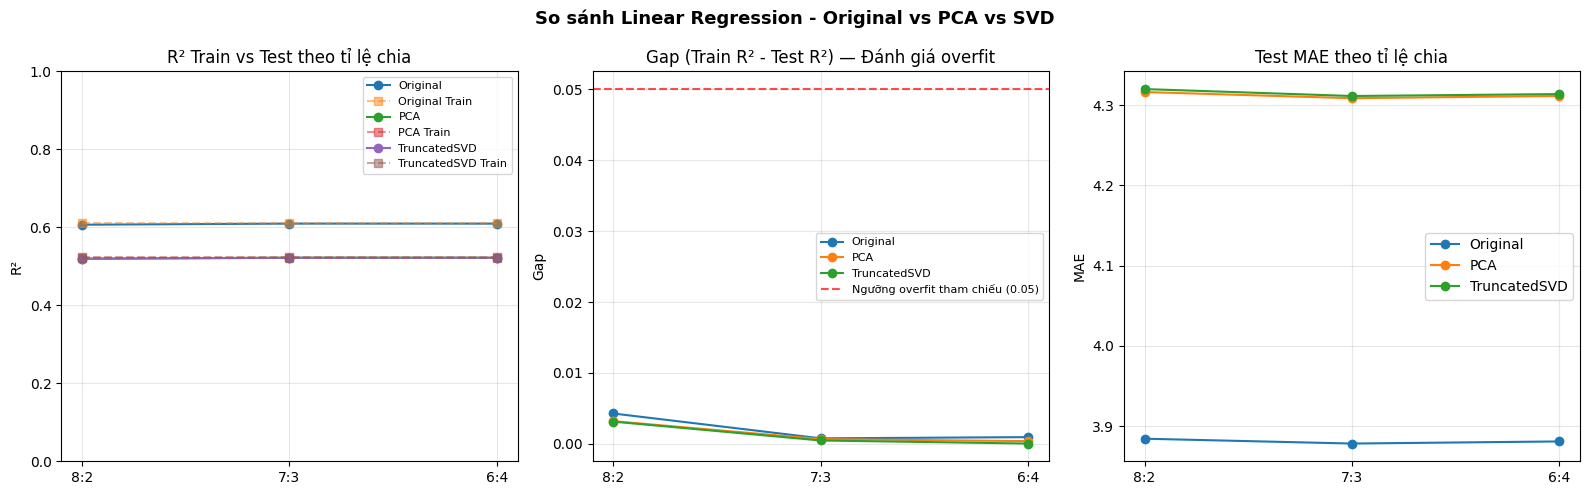

,Data Type,Split (Train:Test),Train R2,Test R2,Gap,Test MAE
0,Original,8:2,0.6109,0.6067,0.0043,3.8842
1,Original,7:3,0.6103,0.6095,0.0008,3.8781
2,Original,6:4,0.6104,0.6094,0.0010,3.8808
3,PCA,8:2,0.5229,0.5197,0.0032,4.3162
4,PCA,7:3,0.5229,0.5222,0.0007,4.3085
5,PCA,6:4,0.5227,0.5223,0.0004,4.3113
6,TruncatedSVD,8:2,0.5222,0.5190,0.0031,4.3199
7,TruncatedSVD,7:3,0.5221,0.5216,0.0005,4.3113
8,TruncatedSVD,6:4,0.5218,0.5217,0.0001,4.3137


In [19]:
df_all = pd.concat([df_orig, df_pca, df_svd], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits_order = ['8:2', '7:3', '6:4']

#Test R2
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[0].plot(splits_order, grp['Test R2'], marker='o', label=dtype)
    axes[0].plot(splits_order, grp['Train R2'], marker='s', linestyle='--', alpha=0.5, label=f'{dtype} Train')
axes[0].set_title('R² Train vs Test theo tỉ lệ chia')
axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

#Gap (Train R2 - Test R2)
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[1].plot(splits_order, grp['Gap'], marker='o', label=dtype)
axes[1].axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Ngưỡng overfit tham chiếu (0.05)')
axes[1].set_title('Gap (Train R² - Test R²) — Đánh giá overfit')
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

#Test MAE
for dtype, grp in df_all.groupby('Data Type'):
    grp = grp.set_index('Split (Train:Test)').loc[splits_order]
    axes[2].plot(splits_order, grp['Test MAE'], marker='o', label=dtype)
axes[2].set_title('Test MAE theo tỉ lệ chia')
axes[2].set_ylabel('MAE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'So sánh Linear Regression - Original vs PCA vs SVD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

display(df_all[['Data Type','Split (Train:Test)','Train R2','Test R2','Gap','Test MAE']].round(4))

Analyzing overfit across sample sizes: 100%|██████████| 1/1 [00:02<00:00,  2.29s/it]


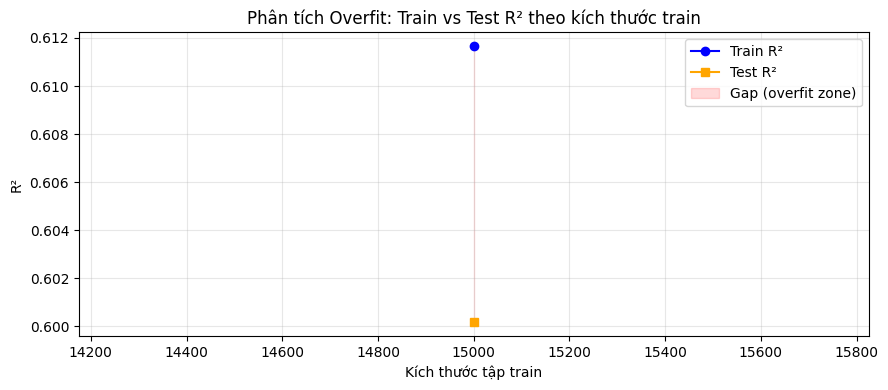


Gap tại size=15000: Train R² - Test R² = 0.6117 - 0.6002 = 0.0115


In [21]:
# Phân tích overfit - LinearRegression (Learning Curve)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)
X_tr, X_te = preprocess_data(X_train_70, X_test_30)

sample_sizes = [15000]
train_r2_list, test_r2_list = [], []

y_tr_all = y_train_70.values
y_te_s   = y_test_30.values[:15000]
X_te_s   = X_te[:15000]

for size in tqdm(sample_sizes, desc="Analyzing overfit across sample sizes"):
    m = LinearRegression()
    m.fit(X_tr[:size], y_tr_all[:size])
    train_r2_list.append(r2_score(y_tr_all[:size], m.predict(X_tr[:size])))
    test_r2_list.append(r2_score(y_te_s,           m.predict(X_te_s)))

plt.figure(figsize=(9, 4))
plt.plot(sample_sizes, train_r2_list, marker='o', label='Train R²', color='blue')
plt.plot(sample_sizes, test_r2_list, marker='s', label='Test R²', color='orange')
plt.fill_between(sample_sizes, train_r2_list, test_r2_list, alpha=0.15, color='red', label='Gap (overfit zone)')
plt.xlabel('Kích thước tập train')
plt.ylabel('R²')
plt.title('Phân tích Overfit: Train vs Test R² theo kích thước train')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_size = sample_sizes[np.argmax(test_r2_list)]
idx = sample_sizes.index(best_size)
print(f"\nGap tại size={best_size}: Train R² - Test R² = "
      f"{train_r2_list[idx]:.4f} - {test_r2_list[idx]:.4f} = "
      f"{train_r2_list[idx] - test_r2_list[idx]:.4f}")

## 5. So sanh chi tiet Original vs PCA vs SVD (chuyen doi tu df_all)

=== So sanh Original / PCA / SVD (split 80/20) ===
    Data   Val_R2  Val_RMSE  Val_MAE  Delta_R2
Original 0.606654  4.855135 3.884180  0.004294
     PCA 0.519707  5.364967 4.316240  0.003212
     SVD 0.519047  5.368649 4.319947  0.003148


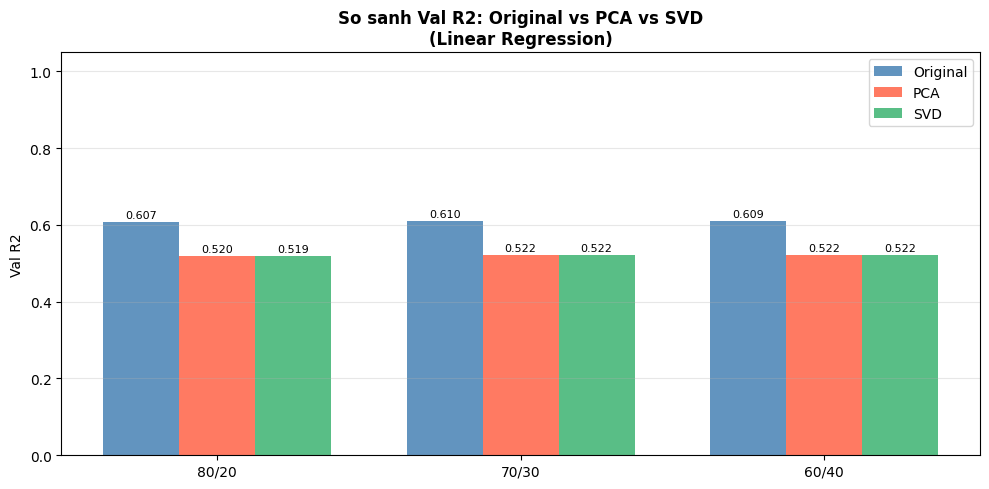

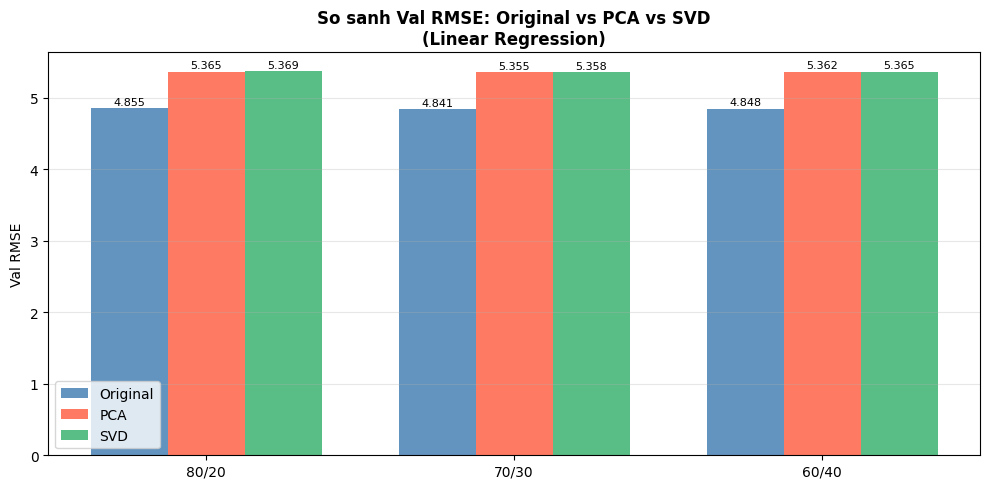


=== Muc giam hieu nang so voi Original (split 80/20) ===
  PCA : dR2=+0.0869  dRMSE=+0.5098
  SVD : dR2=+0.0876  dRMSE=+0.5135


In [22]:
# Tao thu muc luu hinh
FIG_ROOT = os.path.join('..', 'figures', '05_linear_regression')
FIG_METRICS = os.path.join(FIG_ROOT, 'metrics')
FIG_RESID = os.path.join(FIG_ROOT, 'residuals')
os.makedirs(FIG_METRICS, exist_ok=True)
os.makedirs(FIG_RESID, exist_ok=True)

# Chuan hoa df_all ve schema tuong tu results_df cua notebook 04
_type_map = {'Original': 'Original', 'PCA': 'PCA', 'TruncatedSVD': 'SVD', 'SVD': 'SVD'}
_split_map = {'8:2': '80/20', '7:3': '70/30', '6:4': '60/40'}

results_df = df_all.copy()
results_df['Data'] = results_df['Data Type'].map(_type_map).fillna(results_df['Data Type'])
results_df['Split'] = results_df['Split (Train:Test)'].map(_split_map).fillna(results_df['Split (Train:Test)'])
results_df['Val_R2'] = results_df['Test R2']
results_df['Val_MAE'] = results_df['Test MAE']
results_df['Val_RMSE'] = np.sqrt(results_df['Test MSE'])
results_df['Delta_R2'] = results_df['Gap']

split_order = ['80/20', '70/30', '60/40']
results_df['Split'] = pd.Categorical(results_df['Split'], categories=split_order, ordered=True)
results_df = results_df.sort_values(['Data', 'Split']).reset_index(drop=True)

# So sanh chi tiet Original / PCA / SVD
avail = results_df['Data'].unique()
dim_methods = [dt for dt in ['PCA', 'SVD'] if dt in avail]

if len(dim_methods) < 2:
    print('Chua du du lieu de so sanh PCA va SVD (can ca hai).')
else:
    compare_df = results_df[results_df['Data'].isin(['Original'] + dim_methods)].copy()
    print('=== So sanh Original / PCA / SVD (split 80/20) ===')
    sub80 = compare_df[compare_df['Split'] == '80/20']
    print(sub80[['Data', 'Val_R2', 'Val_RMSE', 'Val_MAE', 'Delta_R2']].to_string(index=False))

    # Bieu do Val R2
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(split_order))
    bar_width = 0.25
    colors = {'Original': 'steelblue', 'PCA': 'tomato', 'SVD': 'mediumseagreen'}

    for i, dt in enumerate(['Original'] + dim_methods):
        vals = []
        for s in split_order:
            row = results_df[(results_df['Data'] == dt) & (results_df['Split'] == s)]
            vals.append(row['Val_R2'].iloc[0] if len(row) > 0 else np.nan)

        bars = ax.bar(x + i * bar_width, vals, bar_width,
                      label=dt, color=colors.get(dt, 'gray'), alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                        f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(split_order)
    ax.set_ylabel('Val R2')
    ax.set_title('So sanh Val R2: Original vs PCA vs SVD\n(Linear Regression)', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_METRICS, 'compare_original_pca_svd_r2.png'), bbox_inches='tight')
    plt.show()

    # Bieu do Val RMSE
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, dt in enumerate(['Original'] + dim_methods):
        vals = []
        for s in split_order:
            row = results_df[(results_df['Data'] == dt) & (results_df['Split'] == s)]
            vals.append(row['Val_RMSE'].iloc[0] if len(row) > 0 else np.nan)

        bars = ax.bar(x + i * bar_width, vals, bar_width,
                      label=dt, color=colors.get(dt, 'gray'), alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                        f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(split_order)
    ax.set_ylabel('Val RMSE')
    ax.set_title('So sanh Val RMSE: Original vs PCA vs SVD\n(Linear Regression)', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_METRICS, 'compare_original_pca_svd_rmse.png'), bbox_inches='tight')
    plt.show()

    # Tom tat giam hieu nang so voi Original o split 80/20
    base_row = results_df[(results_df['Data'] == 'Original') & (results_df['Split'] == '80/20')]
    if len(base_row) > 0:
        orig_r2 = base_row['Val_R2'].iloc[0]
        orig_rmse = base_row['Val_RMSE'].iloc[0]
        print('\n=== Muc giam hieu nang so voi Original (split 80/20) ===')
        for dt in dim_methods:
            row = results_df[(results_df['Data'] == dt) & (results_df['Split'] == '80/20')]
            if len(row) == 0:
                continue
            dr2 = orig_r2 - row['Val_R2'].iloc[0]
            drmse = row['Val_RMSE'].iloc[0] - orig_rmse
            print(f'  {dt:4s}: dR2={dr2:+.4f}  dRMSE={drmse:+.4f}')
    else:
        print('Khong tim thay dong Original cho split 80/20 de tinh muc giam.')

## 6. Residual Analysis (tuong tu notebook 04)

[OK] Da tao residuals cho Original
[OK] Da tao residuals cho PCA
[OK] Da tao residuals cho SVD


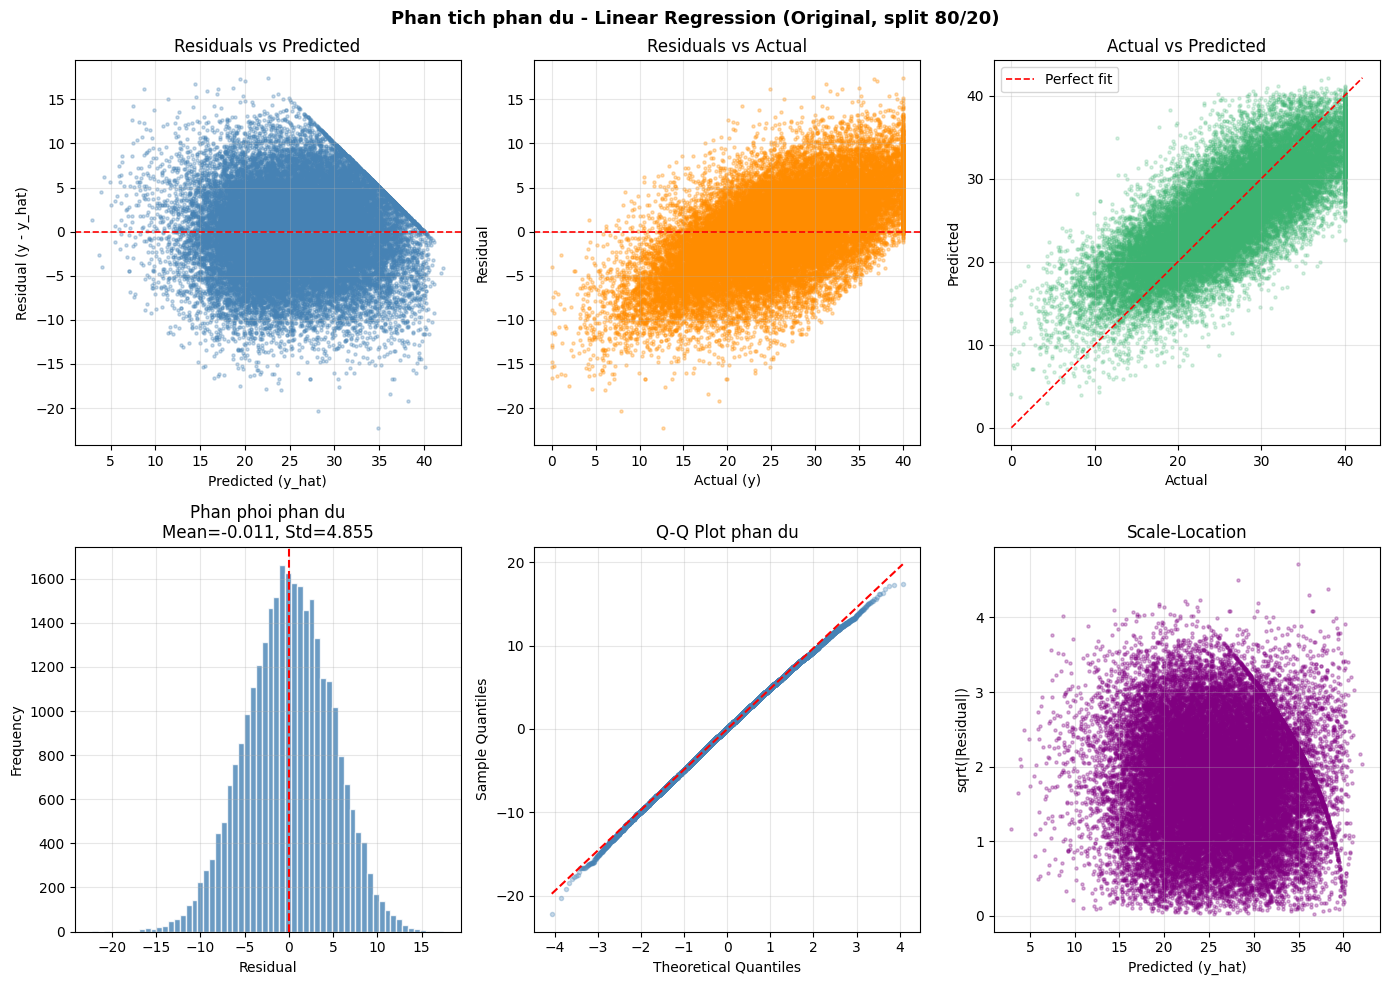

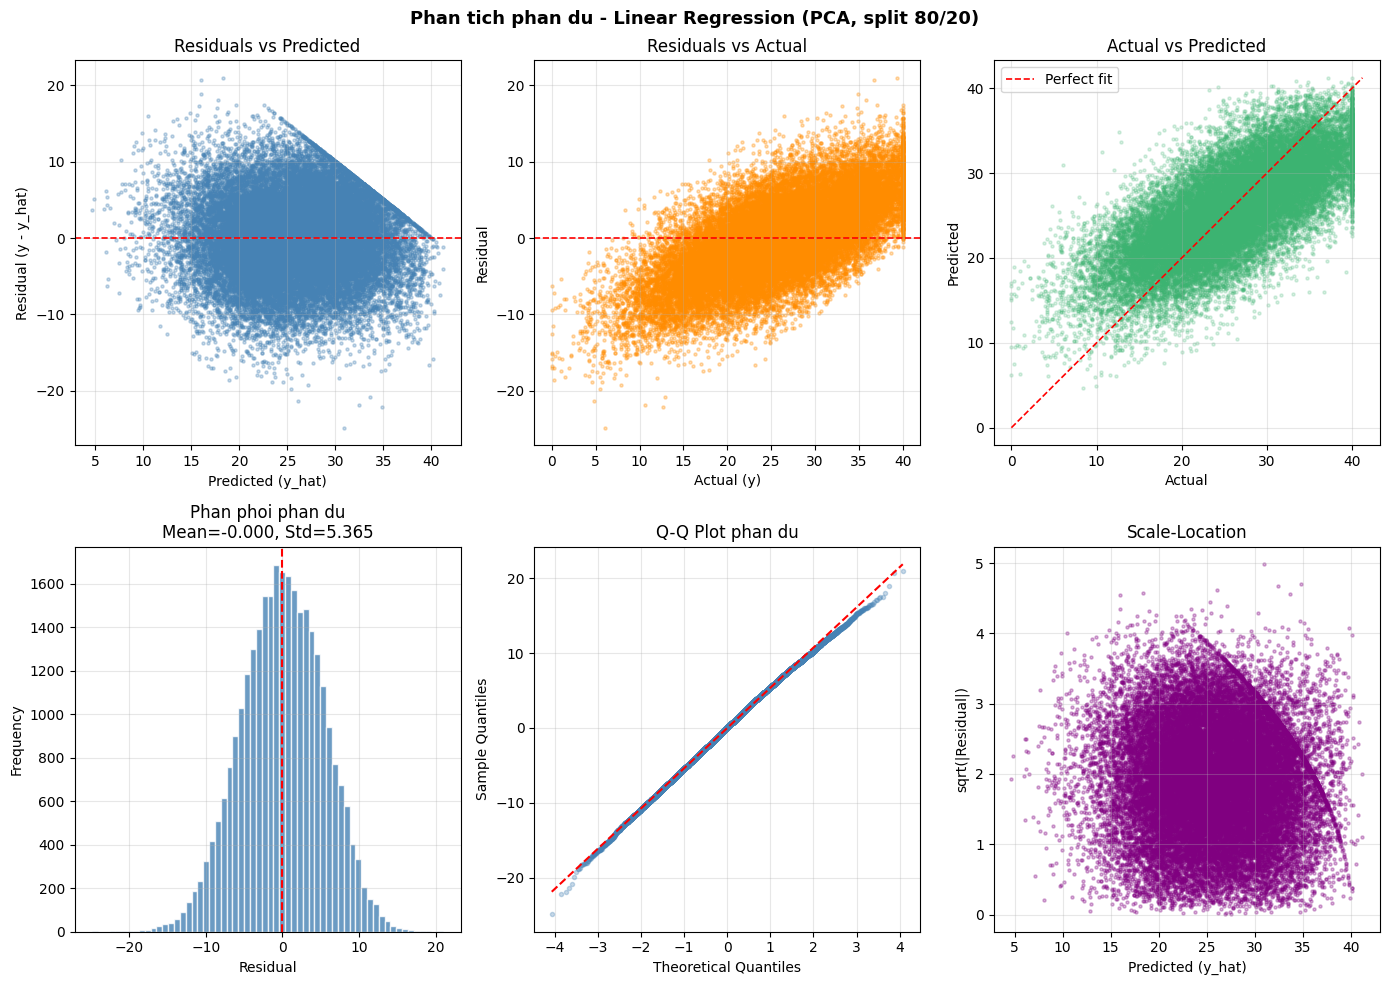

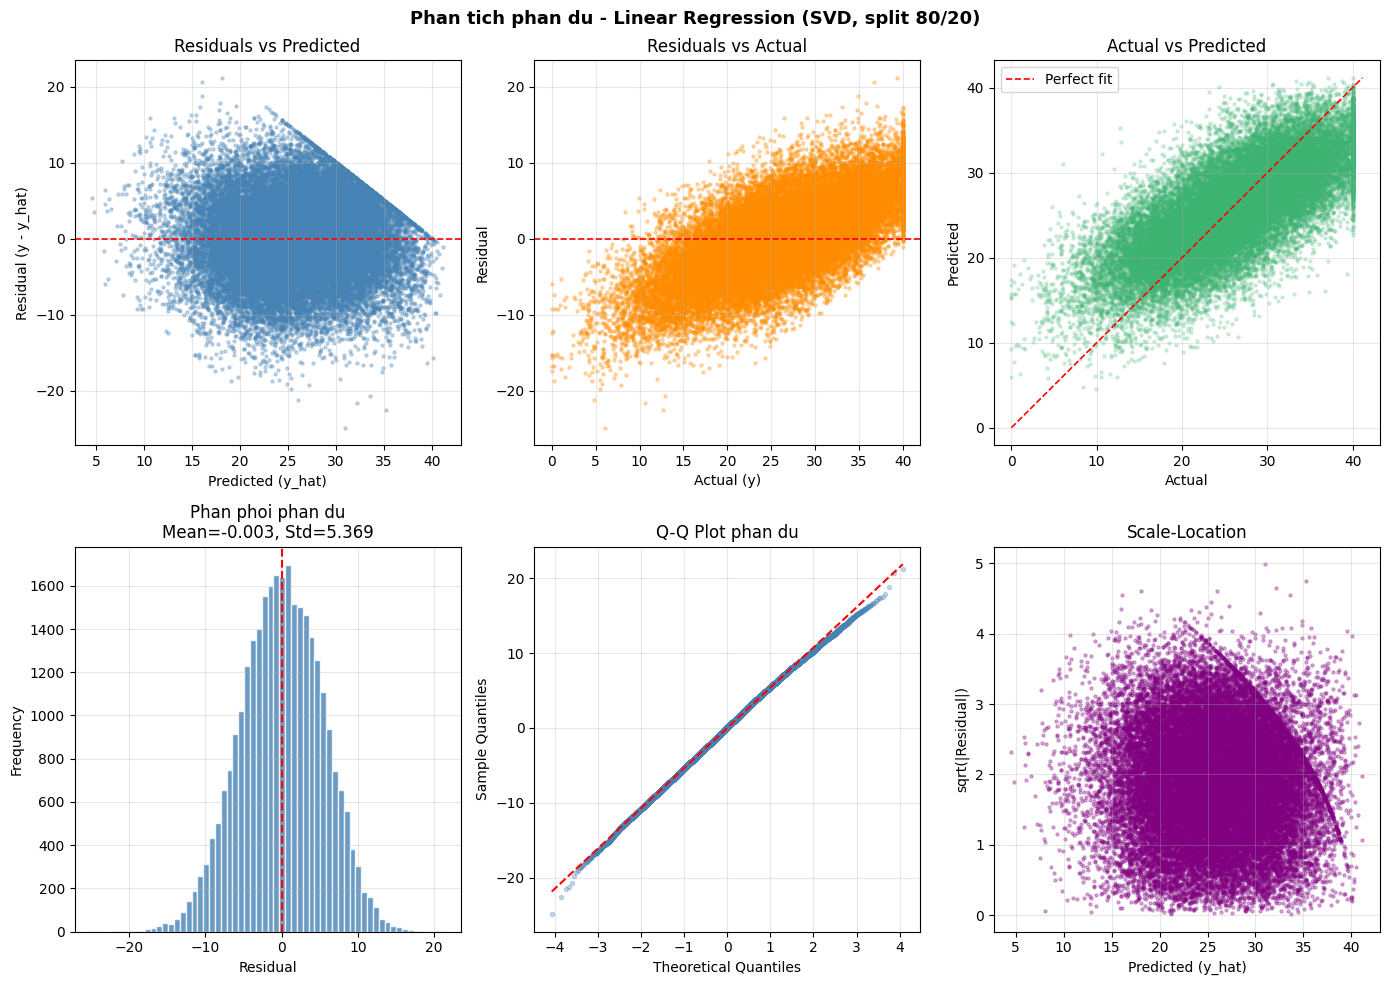

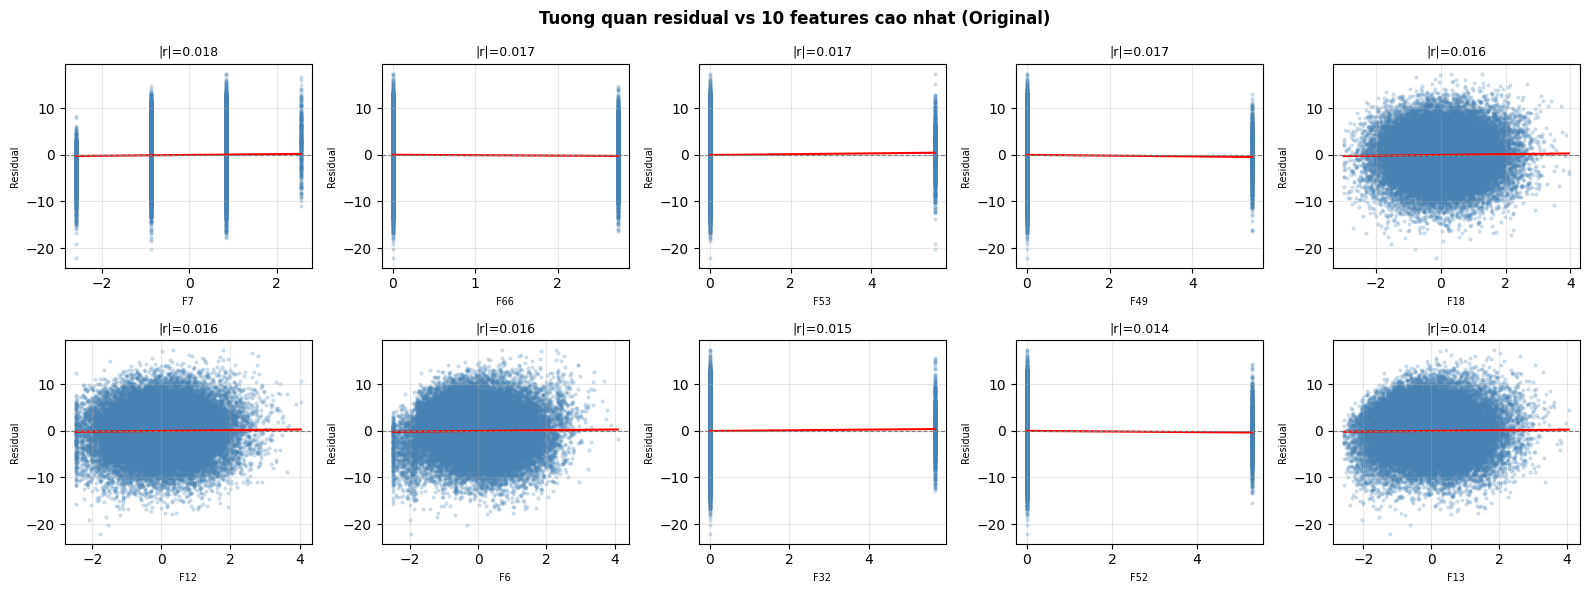


[Original] Top 10 |r| residual vs features:
F7     0.018225
F66    0.017296
F53    0.017206
F49    0.016827
F18    0.016253
F12    0.015923
F6     0.015644
F32    0.014951
F52    0.014104
F13    0.014064


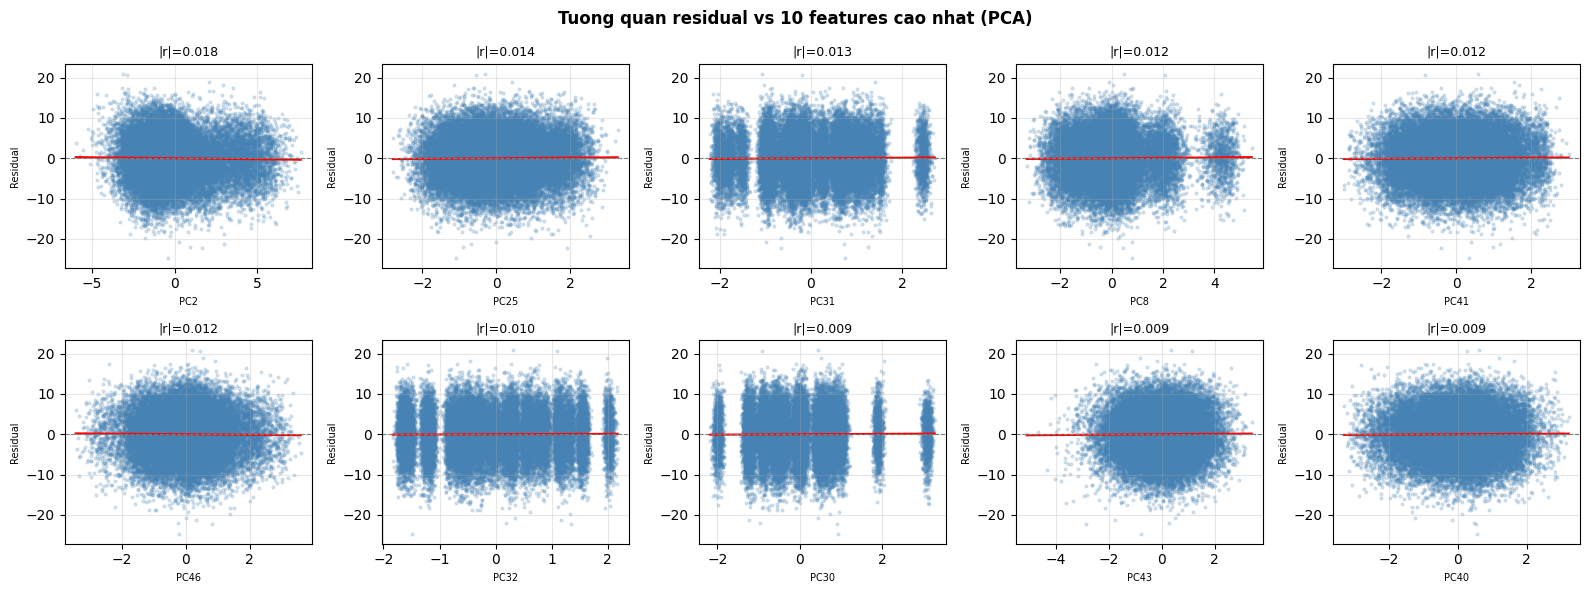


[PCA] Top 10 |r| residual vs features:
PC2     0.017539
PC25    0.013581
PC31    0.013060
PC8     0.012343
PC41    0.011849
PC46    0.011756
PC32    0.009711
PC30    0.009152
PC43    0.009021
PC40    0.008997


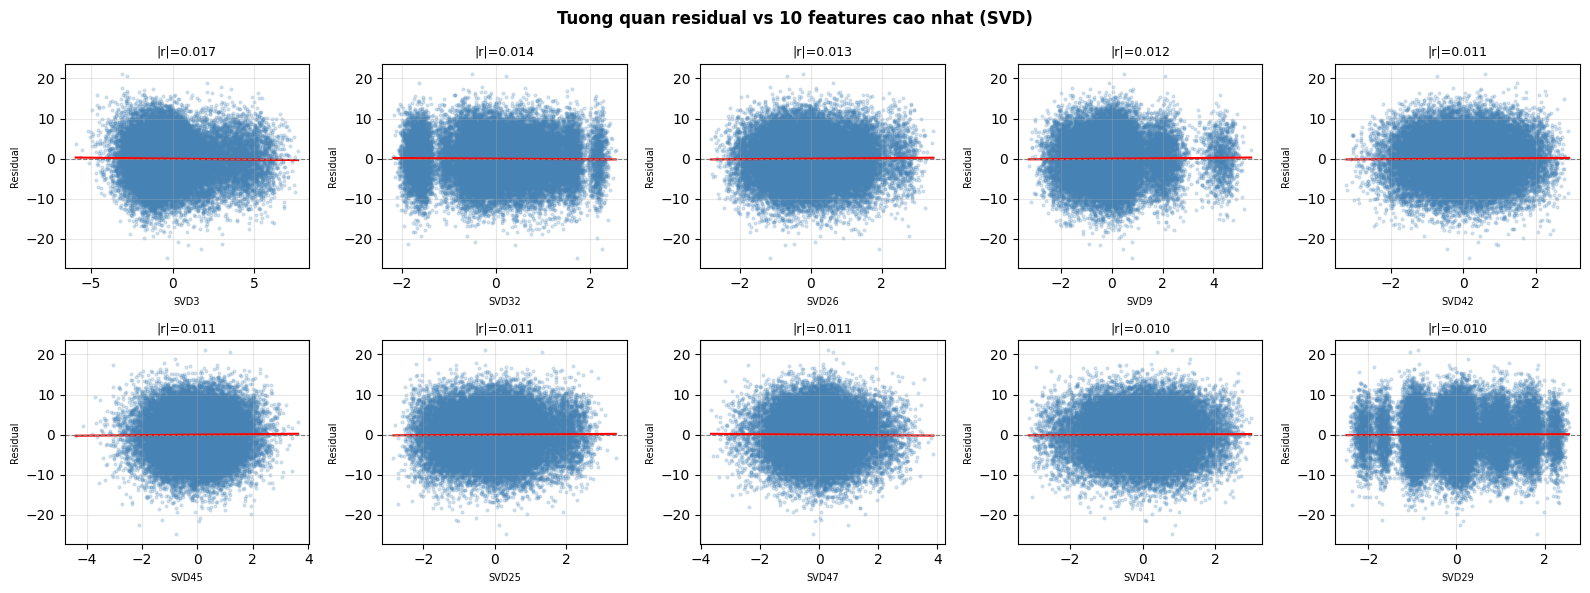


[SVD] Top 10 |r| residual vs features:
SVD3     0.017307
SVD32    0.014077
SVD26    0.012701
SVD9     0.012230
SVD42    0.011347
SVD45    0.011300
SVD25    0.011192
SVD47    0.010850
SVD41    0.009766
SVD29    0.009541

Kiem dinh residual - Original
  Mean    : -0.0110  (gan 0 -> it bias)
  Std     : 4.8551
  Skewness: -0.1024
  Kurtosis: -0.0504
  KS test (normal): stat=0.0095, p=8.4894e-03
  -> Residual KHONG phan phoi chuan (p < 0.05)

Kiem dinh residual - PCA
  Mean    : -0.0003  (gan 0 -> it bias)
  Std     : 5.3650
  Skewness: -0.0892
  Kurtosis: -0.1154
  KS test (normal): stat=0.0116, p=6.4935e-04
  -> Residual KHONG phan phoi chuan (p < 0.05)

Kiem dinh residual - SVD
  Mean    : -0.0030  (gan 0 -> it bias)
  Std     : 5.3686
  Skewness: -0.0885
  Kurtosis: -0.1158
  KS test (normal): stat=0.0112, p=1.1002e-03
  -> Residual KHONG phan phoi chuan (p < 0.05)


In [23]:
import scipy.stats as stats
from scipy.stats import kstest


def _safe_corr(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.std() == 0 or b.std() == 0:
        return 0.0
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) else c


def _fit_and_collect_residuals(method='Original', test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

    if method == 'Original':
        X_tr_use = X_train_combined
        X_te_use = X_test_combined
        feat_names = [f'F{i+1}' for i in range(X_te_use.shape[1])]
    elif method == 'PCA':
        reducer = PCA(n_components=0.8, random_state=42)
        X_tr_use = reducer.fit_transform(X_train_combined)
        X_te_use = reducer.transform(X_test_combined)
        feat_names = [f'PC{i+1}' for i in range(X_te_use.shape[1])]
    elif method == 'SVD':
        n_components = min(47, max(2, X_train_combined.shape[1] - 1))
        reducer = TruncatedSVD(n_components=n_components, random_state=42)
        X_tr_use = reducer.fit_transform(X_train_combined)
        X_te_use = reducer.transform(X_test_combined)
        feat_names = [f'SVD{i+1}' for i in range(X_te_use.shape[1])]
    else:
        raise ValueError(f'method khong hop le: {method}')

    model = LinearRegression()
    model.fit(X_tr_use, y_train)

    y_pred = model.predict(X_te_use)
    y_val = np.asarray(y_test)
    residuals = y_val - y_pred

    X_val_df = pd.DataFrame(X_te_use, columns=feat_names)

    return {
        'residuals': residuals,
        'y_pred': y_pred,
        'y_val': y_val,
        'X_val': X_val_df,
        'model': model,
    }


residuals_store = {}
for data_type in ['Original', 'PCA', 'SVD']:
    try:
        residuals_store[data_type] = _fit_and_collect_residuals(method=data_type, test_size=0.2)
        print(f'[OK] Da tao residuals cho {data_type}')
    except Exception as e:
        print(f'[SKIP] {data_type}: {e}')

# 6.1 Bieu do co ban: Residuals vs Predicted, phan phoi, Q-Q, Scale-Location
for data_type in [dt for dt in ['Original', 'PCA', 'SVD'] if dt in residuals_store]:
    store = residuals_store[data_type]
    resid = store['residuals']
    y_pred = store['y_pred']
    y_val = store['y_val']

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f'Phan tich phan du - Linear Regression ({data_type}, split 80/20)',
                 fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(2, 3, figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_pred, resid, alpha=0.3, s=5, color='steelblue')
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax1.set_xlabel('Predicted (y_hat)')
    ax1.set_ylabel('Residual (y - y_hat)')
    ax1.set_title('Residuals vs Predicted')
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_val, resid, alpha=0.3, s=5, color='darkorange')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax2.set_xlabel('Actual (y)')
    ax2.set_ylabel('Residual')
    ax2.set_title('Residuals vs Actual')
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(y_val, y_pred, alpha=0.2, s=5, color='mediumseagreen')
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax3.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect fit')
    ax3.set_xlabel('Actual')
    ax3.set_ylabel('Predicted')
    ax3.set_title('Actual vs Predicted')
    ax3.legend()
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(resid, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'Phan phoi phan du\nMean={resid.mean():.3f}, Std={resid.std():.3f}')
    ax4.grid(alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 1])
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax5.plot(osm, osr, 'o', alpha=0.3, markersize=3, color='steelblue')
    ax5.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
    ax5.set_xlabel('Theoretical Quantiles')
    ax5.set_ylabel('Sample Quantiles')
    ax5.set_title('Q-Q Plot phan du')
    ax5.grid(alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.scatter(y_pred, np.sqrt(np.abs(resid)), alpha=0.3, s=5, color='purple')
    ax6.set_xlabel('Predicted (y_hat)')
    ax6.set_ylabel('sqrt(|Residual|)')
    ax6.set_title('Scale-Location')
    ax6.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_RESID, f'residual_analysis_{data_type}.png'), bbox_inches='tight')
    plt.show()

# 6.2 Tuong quan residual vs features chinh
for data_type in [dt for dt in ['Original', 'PCA', 'SVD'] if dt in residuals_store]:
    store = residuals_store[data_type]
    resid = store['residuals']
    X_val = store['X_val']

    corr_resid = X_val.apply(lambda col: _safe_corr(col.values, resid))
    top_corr = corr_resid.abs().nlargest(10)

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    fig.suptitle(f'Tuong quan residual vs 10 features cao nhat ({data_type})',
                 fontsize=12, fontweight='bold')
    axes = axes.flatten()

    for i, feat in enumerate(top_corr.index):
        axes[i].scatter(X_val[feat], resid, alpha=0.2, s=4, color='steelblue')
        z = np.polyfit(X_val[feat], resid, 1)
        p = np.poly1d(z)
        xs = np.linspace(X_val[feat].min(), X_val[feat].max(), 100)
        axes[i].plot(xs, p(xs), 'r-', linewidth=1.5)
        axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[i].set_xlabel(feat, fontsize=7)
        axes[i].set_ylabel('Residual', fontsize=7)
        axes[i].set_title(f'|r|={top_corr[feat]:.3f}', fontsize=9)
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_RESID, f'residual_features_{data_type}.png'), bbox_inches='tight')
    plt.show()

    print(f'\n[{data_type}] Top 10 |r| residual vs features:')
    print(top_corr.to_string())

# 6.3 Kiem dinh thong ke residual
for data_type in [dt for dt in ['Original', 'PCA', 'SVD'] if dt in residuals_store]:
    resid = residuals_store[data_type]['residuals']
    std = resid.std()

    print(f"\n{'='*50}")
    print(f'Kiem dinh residual - {data_type}')
    print(f"{'='*50}")
    print(f'  Mean    : {resid.mean():.4f}  (gan 0 -> it bias)')
    print(f'  Std     : {std:.4f}')
    print(f'  Skewness: {pd.Series(resid).skew():.4f}')
    print(f'  Kurtosis: {pd.Series(resid).kurtosis():.4f}')

    if std == 0:
        print('  KS test (normal): bo qua vi std = 0')
        continue

    ks_stat, ks_p = kstest((resid - resid.mean()) / std, 'norm')
    print(f'  KS test (normal): stat={ks_stat:.4f}, p={ks_p:.4e}')
    if ks_p < 0.05:
        print('  -> Residual KHONG phan phoi chuan (p < 0.05)')
    else:
        print('  -> Residual co the phan phoi chuan (p >= 0.05)')